# Monte Carlo for Blackjack

In this notebook, we will use Monte Carlo to solve Blackjack.

Environment: (https://gymnasium.farama.org/environments/toy_text/blackjack/).

In [1]:
%%capture
!pip install gymnasium
!pip install numpy

In [2]:
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import random
import sys
from collections import defaultdict
from gymnasium.envs.toy_text.blackjack import BlackjackEnv
from gymnasium.envs.toy_text.blackjack import draw_hand, sum_hand, score

matplotlib.style.use('ggplot')
%matplotlib inline

### Blackjack Environment

[How-to-play-blackjack](https://bicyclecards.com/how-to-play/blackjack/)

Blackjack is a card game where the goal is to obtain cards that sum to as near as possible to 21 without going over. They're playing against a fixed dealer.

* Face cards (Jack, Queen, King) have point value 10.
* Aces can either count as 11 or 1, and it's called 'usable' at 11.
* This game is placed with an infinite deck (or with replacement).
* The game starts with each (player and dealer) having one face up and one
face down card.

The player can request additional cards (hit=1) until they decide to stop
(stick=0) or exceed 21 (bust).

After the player sticks, the dealer reveals their facedown card, and draws
until their sum is 17 or greater.  If the dealer goes bust the player wins.

If neither player nor dealer busts, the outcome (win, lose, draw) is
decided by whose sum is closer to 21.  The reward for winning is +1,
drawing is 0, and losing is -1.

The observation of a 3-tuple of:

* the players current sum,
* the dealer's one showing card (1-10 where 1 is ace),
* whether or not the player holds a usable ace (0 or 1).


In [3]:
env = gym.make('Blackjack-v1', render_mode="rgb_array", natural=False, sab=False)

In [4]:
# random seed to draw a hand, it's sum and score
hand = draw_hand(env.np_random)
print ("Draw a random hand:", hand) # 2 cards of value
print ("Total of current hand:", sum_hand(hand)) # total value of hands
print ("Score of current hand:", score(hand)) # (busted=0) if sum > 21

Draw a random hand: [1, 7]
Total of current hand: 18
Score of current hand: 18


In [5]:
# actions: stick=0, hit=1
actions = ["stick", "hit"]

In [6]:
# Current observation : players current sum, dealer's card, usable ace
curr_observation, info = env.reset()
print ("Current observation:", curr_observation)
print ("Player's card:", env.get_wrapper_attr('player'))
print ("Dealer's card:", env.get_wrapper_attr('dealer'))

Current observation: (17, 7, 0)
Player's card: [7, 10]
Dealer's card: [7, 6]


In [7]:
# Taking a step by selecting a random action[stick=0, hit=1] from current state
# next_obs: 3-tuple of (player's current sum, dealer's one card, usable ace)
# reward: What rewards did I recieve?
# is_terminal: did I end up in the goal state?

# Player lost, dealer sum > Player sum
# sample a random action from all valid actions
action = env.action_space.sample()
print ("Action taken:", actions[action])

observation, reward, terminated, truncated, info = env.step(action)
curr_observation = observation
is_terminal = terminated or truncated

print ("Player's card:", env.get_wrapper_attr('player'))
print ("Dealer's card:", env.get_wrapper_attr('dealer'))
print ("Next observation:", observation)
print ("Reward received:", reward)
print ("Terminal state:", is_terminal)

Action taken: stick
Player's card: [7, 10]
Dealer's card: [7, 6, 2, 2]
Next observation: (17, 7, 0)
Reward received: 0.0
Terminal state: True


In [8]:
def sample_policy(observation):
    """
    A policy that sticks if the player score is > 20 and hits otherwise.
    """
    score, dealer_score, usable_ace = observation
    return 0 if score >= 20 else 1

In [9]:
# generate a episode in blackjack environment for above sample_policy
def generate_episode(policy, verbose=False):
    episode = []
    env = gym.make('Blackjack-v1', natural=False, sab=False)
    curr_observation, info = env.reset()

    while True:
        if verbose:
            print ("Current observation:", curr_observation)
            print ("Player's card:", env.get_wrapper_attr('player'))
            print ("Dealer's card:", env.get_wrapper_attr('dealer')[0])

        action = policy(curr_observation)
        next_observation, reward, terminated, truncated, info = env.step(action)
        is_terminal = terminated or truncated

        if verbose:
            print ("Action taken:", actions[action])
            print ("Player's card:", env.get_wrapper_attr('player'))
            if action:
                print ("Dealer's card:", env.get_wrapper_attr('dealer')[0])
            else:
                print ("Dealer's card:", env.get_wrapper_attr('dealer'))
            print ("Next observation:", next_observation)
            print ("Reward received:", reward)
            print ("Terminal state:", is_terminal)
            print ("-"*20)
        episode.append((curr_observation, action, reward))

        curr_observation = next_observation
        if (is_terminal):
            break
    return episode

In [10]:
e = generate_episode(sample_policy, True)
print ("Episode:", e)

Current observation: (15, 10, 0)
Player's card: [5, 10]
Dealer's card: 10
Action taken: hit
Player's card: [5, 10, 9]
Dealer's card: 10
Next observation: (24, 10, 0)
Reward received: -1.0
Terminal state: True
--------------------
Episode: [((15, 10, 0), 1, -1.0)]


### Monte Carlo Prediction

#### First Visit

 Each occurrence of state $s$ in an episode is called a visit to $s$.

$$ \begin{aligned} V(s_{t}) &= V(s_{t}) + \frac{1}{N(s_{t})}(G_{t} - V(s_{t})),\end{aligned} $$

where $G_{t}$ is total return from time step $t$ and $N(s_{t})$ keeps track of visits to state $s_{t}$.

![first visit](https://github.com/dudeperf3ct/RL_Notebooks/blob/master/MC/images/mc_first_visit.png?raw=1)

In [11]:
def mc_prediction(policy, env, num_episodes, discount_factor=1.0):
    """
    Monte Carlo prediction algorithm. Calculates the value function
    for a given policy using sampling.

    Args:
        policy: A function that maps an observation to action probabilities.
        env: OpenAI gym environment.
        num_episodes: Number of episodes to sample.
        discount_factor: Gamma discount factor.

    Returns:
        A dictionary that maps from state -> value.
        The state is a tuple and the value is a float.
    """

    def state_returns(state, episode):
        rt = 0
        tmp = 0
        for i, e in enumerate(episode):
            if (e[0] == state):
                tmp = i
                break
        # get total return from state
        rt = sum([x[2]*(discount_factor**i) for i,x in enumerate(episode[tmp:])])
        return rt

    # Keeps track of sum and count of returns for each state
    # to calculate an average. We could use an array to save all
    # returns (like in the book) but that's memory inefficient.
    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)
    # The final value function
    V = defaultdict(float)

    for n in range(num_episodes):
        ep = generate_episode(policy, False)

        states_in_episode = set([tuple(e[0]) for e in ep])
        for state in states_in_episode:
            G = state_returns(state, ep)
            returns_sum[state] += G
            returns_count[state] += 1
            V[state] = returns_sum[state] / returns_count[state]

    return V

In [12]:
def plot_value_function(V, title="Value Function"):
    """
    Plots the value function as a surface plot.
    """
    min_x = min(k[0] for k in V.keys())
    max_x = max(k[0] for k in V.keys())
    min_y = min(k[1] for k in V.keys())
    max_y = max(k[1] for k in V.keys())

    x_range = np.arange(min_x, max_x + 1)
    y_range = np.arange(min_y, max_y + 1)
    X, Y = np.meshgrid(x_range, y_range)

    # Find value for all (x, y) coordinates
    Z_noace = np.apply_along_axis(lambda _: V[(_[0], _[1], False)], 2, np.dstack([X, Y]))
    Z_ace = np.apply_along_axis(lambda _: V[(_[0], _[1], True)], 2, np.dstack([X, Y]))

    def plot_surface(X, Y, Z, title):
        fig = plt.figure(figsize=(10, 5))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                               cmap=matplotlib.cm.coolwarm, vmin=-1.0, vmax=1.0)
        ax.set_xlabel('Player Sum')
        ax.set_ylabel('Dealer Showing')
        ax.set_zlabel('Value')
        ax.set_title(title)
        ax.view_init(ax.elev, -120)
        fig.colorbar(surf)
        plt.show()

    plot_surface(X, Y, Z_noace, "{} (No Usable Ace)".format(title))
    plot_surface(X, Y, Z_ace, "{} (Usable Ace)".format(title))

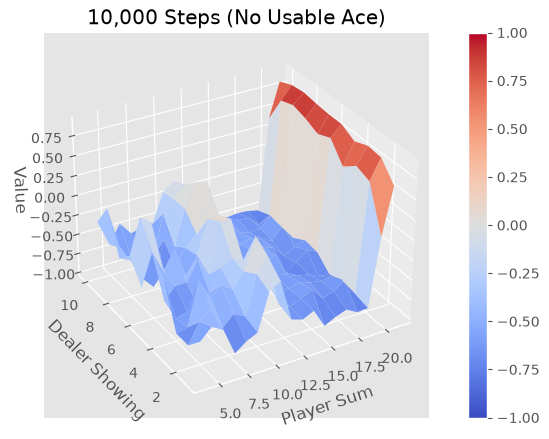

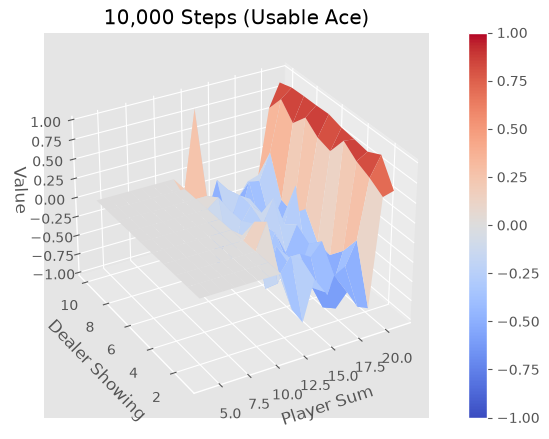

CPU times: user 1.11 s, sys: 73 ms, total: 1.18 s
Wall time: 1.18 s


In [13]:
%%time
V_10k = mc_prediction(sample_policy, env, num_episodes=10000)
plot_value_function(V_10k, title="10,000 Steps")

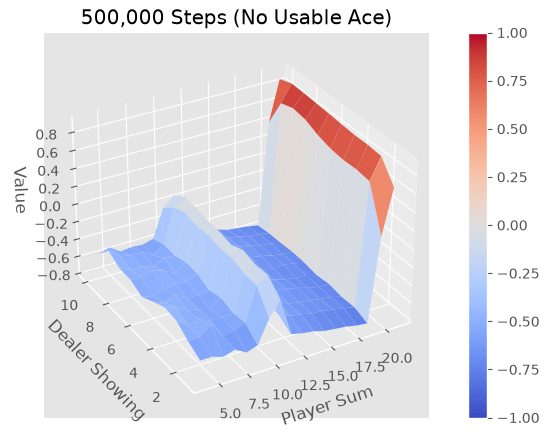

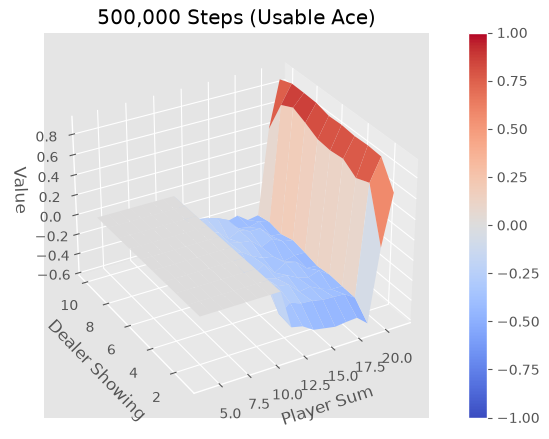

CPU times: user 48.3 s, sys: 1.68 s, total: 50 s
Wall time: 50.2 s


In [14]:
%%time
V_500k = mc_prediction(sample_policy, env, num_episodes=500000)
plot_value_function(V_500k, title="500,000 Steps")

### Monte Carlo Control with $\epsilon$-greedy policy (On-policy)

$\epsilon$-greedy policy:

$$ 
\begin{aligned} \pi(a \vert s) = \begin{cases} \frac{\epsilon}{m} + 1 - \epsilon &\text{if } a = argmax_{a \in \mathcal{A}}Q(s, a)\\ \frac{\epsilon}{m} & otherwise \end{cases} \end{aligned} 
$$

![mc_control](https://github.com/dudeperf3ct/RL_Notebooks/blob/master/MC/images/mc_control.png?raw=1)


In [15]:
def make_epsilon_greedy_policy(Q, epsilon, nA):
    """
    Creates an epsilon-greedy policy based on a given Q-function and epsilon.

    Args:
        Q: A dictionary that maps from state -> action-values.
            Each value is a numpy array of length nA (see below)
        epsilon: The probability to select a random action float between 0 and 1.
        nA: Number of actions in the environment.

    Returns:
        A function that takes the observation as an argument and returns
        the probabilities for each action in the form of a numpy array of length nA.

    """
    def policy_fn(observation):
        pi = np.ones(nA, dtype=float) * (epsilon/nA)
        best_action = np.argmax(Q[observation])
        pi[best_action] += (1.0 - epsilon)
        return pi

    return policy_fn

In [16]:
# generate a episode in blackjack environment for above sample_policy
def generate_episode(policy, verbose=False):
    episode = []
    env = gym.make('Blackjack-v1', natural=False, sab=False)
    curr_observation, info = env.reset()

    while True:
        if verbose:
            print ("Current observation:", curr_observation)
            print ("Player's card:", env.get_wrapper_attr('player'))
            print ("Dealer's card:", env.get_wrapper_attr('dealer')[0])

        probs = policy(curr_observation)
        action = np.random.choice(a=np.arange(len(probs)), p=probs)
        next_observation, reward, terminated, truncated, info = env.step(action)
        is_terminal = terminated or truncated

        if verbose:
            print ("Action taken:", actions[action])
            print ("Player's card:", env.get_wrapper_attr('player'))
            if action:
                print ("Dealer's card:", env.get_wrapper_attr('dealer')[0])
            else:
                print ("Dealer's card:", env.get_wrapper_attr('dealer'))
            print ("Next observation:", next_observation)
            print ("Reward received:", reward)
            print ("Terminal state:", is_terminal)
            print ("-"*20)
        episode.append((curr_observation, action, reward))

        curr_observation = next_observation
        if (is_terminal):
            break
    return episode

In [17]:
Q = defaultdict(lambda: np.zeros(env.action_space.n))
policy = make_epsilon_greedy_policy(Q, 0.1, env.action_space.n)
e = generate_episode(policy, True)
print ("Episode:", e)

Current observation: (19, 1, 0)
Player's card: [9, 10]
Dealer's card: 1
Action taken: stick
Player's card: [9, 10]
Dealer's card: [1, 8]
Next observation: (19, 1, 0)
Reward received: 0.0
Terminal state: True
--------------------
Episode: [((19, 1, 0), np.int64(0), 0.0)]


In [18]:
def mc_control_epsilon_greedy(env, num_episodes, discount_factor=1.0, epsilon=0.1):
    """
    Monte Carlo Control using Epsilon-Greedy policies.
    Finds an optimal epsilon-greedy policy.

    Args:
        env: OpenAI gym environment.
        num_episodes: Number of episodes to sample.
        discount_factor: Gamma discount factor.
        epsilon: Chance the sample a random action. Float betwen 0 and 1.

    Returns:
        A tuple (Q, policy).
        Q is a dictionary mapping state -> action values.
        policy is a function that takes an observation as an argument and returns
        action probabilities
    """

    # Keeps track of sum and count of returns for each state
    # to calculate an average. We could use an array to save all
    # returns (like in the book) but that's memory inefficient.
    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)

    # The final action-value function.
    # A nested dictionary that maps state -> (action -> action-value).
    Q = defaultdict(lambda: np.zeros(env.action_space.n))

    # epsilon-greedy policy
    policy = make_epsilon_greedy_policy(Q, epsilon, env.action_space.n)

    def state_action_returns(state, action, episode):
        rt = 0
        tmp = 0
        for i, e in enumerate(episode):
            if (e[0] == state and e[1] == action):
                tmp = i
                break
        # get total return from state
        rt = sum([x[2]*(discount_factor**i) for i,x in enumerate(episode[tmp:])])
        return rt

    for n in range(num_episodes):
        ep = generate_episode(policy, False)

        states_action_in_episode = set([(tuple(e[0]), e[1]) for e in ep])

        for state_action in states_action_in_episode:
            state, action = state_action
            G = state_action_returns(state, action, ep)
            returns_sum[state_action] += G
            returns_count[state_action] += 1
            Q[state][action] = returns_sum[state_action] / returns_count[state_action]

    return Q, policy

In [19]:
%%time
Q, policy = mc_control_epsilon_greedy(env, num_episodes=500000, epsilon=0.1)

CPU times: user 57.6 s, sys: 1.46 s, total: 59 s
Wall time: 59.3 s


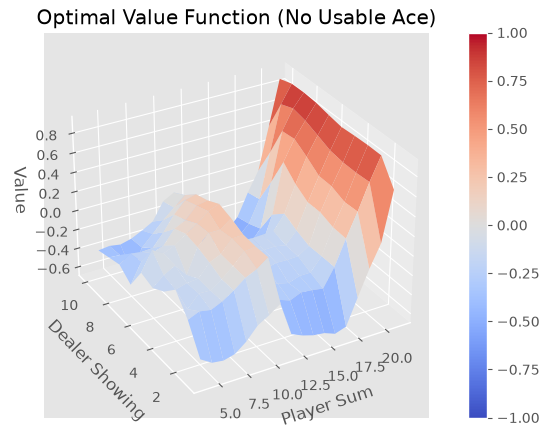

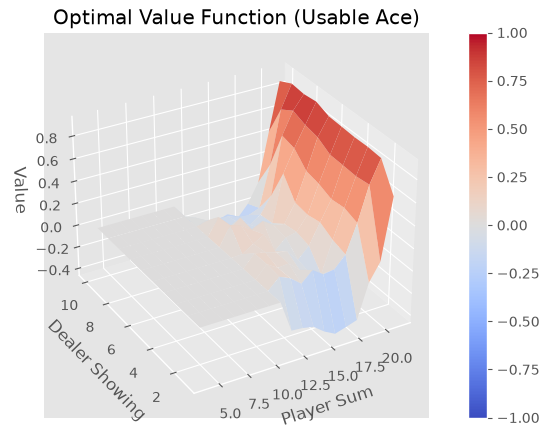

In [20]:
# For plotting: Create value function from action-value function
# by picking the best action at each state
V = defaultdict(float)

for state, actions in Q.items():
    action_value = np.max(actions)
    V[state] = action_value

plot_value_function(V, title="Optimal Value Function")